<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
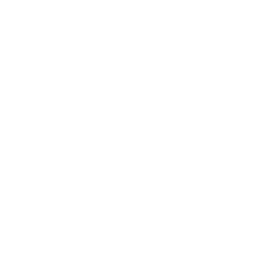
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Shlukování režimů poruch ve výrobě</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Výroba / Řízení kvality &nbsp;|&nbsp; březen 2026</p>
</div>
</div>
</div>

## Shrnutí pro vedení

Tento příklad odhaluje opakující se **režimy poruch zařízení** z vícerozměrného symptomatického profilu snímačů zaznamenaného při každé poruchové události. Osm standardizovaných symptomatických proměnných (vibrace, teplotní rozdíl, pokles tlaku, proudová špička, hluk, odchylka doby cyklu, rozptyl krouticího momentu, počet částic v oleji) je shlukováno pomocí **hierarchického shlukování s úplným propojením (complete linkage)** (`PROC CLUSTER METHOD=COMPLETE`), které upřednostňuje kompaktní a dobře oddělené skupiny. `PROC TREE` následně rozřezává hierarchii na **šest režimů poruch** a `PROC FREQ` křížově tabuluje tyto režimy vůči typu zařízení a směně, aby otestoval systematické souvislosti.

Zdejší běh se provádí na **vzorku 100 událostí** (prostředí omezuje výstup na 100 pozorování). Na tomto vzorku je šest režimů zhruba stejně velkých (n = 16–17 každý) a jsou odděleny především signaturami **teploty, tlaku a vibrací**, nikoli typem zařízení — křížové tabulace režim × zařízení a režim × směna **nejsou** při této velikosti vzorku statisticky významné (chí-kvadrát p = 0,15, resp. p = 0,07). Pracovní postup se beze změn škáluje na celou historii událostí, kde by vyšší počty na jeden režim tyto souvislosti zostřily.

## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|---------|
| WORK.FAILURES | Symptomatické profily poruchových událostí zařízení (syntetické) | 100 |
| WORK.FAILURES_STD | Symptomy standardizované na průměr 0, směrodatnou odchylku 1 (`PROC STANDARD`) | 100 |
| WORK.FAILURE_TREE | Historie slučování při úplném propojení (`OUTTREE=`) | 100 |
| WORK.FAILURE_MODE_ASSIGNMENTS | Rozřezání na šest režimů z `PROC TREE NCLUSTERS=6` | 100 |

*Toto prostředí běží v nelicencovaném režimu a omezuje výstup na 100 pozorování; syntetický generátor požaduje 20 000 událostí, ale ponechá se pouze prvních 100. Následující analýza vychází výhradně z tohoto vzorku 100 událostí.*

---

In [1]:
/* --------------------------------------------------------
   Generuj syntetické symptomatické profily poruchových událostí
   20 000 poruchových událostí napříč 50 kusy zařízení
   -------------------------------------------------------- */
data work.failures;
    CALL streaminit(42);
    POLE equip_type_list[4] $16 _temporary_ ('LIS' 'DOPRAVNIK' 'ROBOT_RAMENO' 'PEC');
    POLE shift_list[3] $16 _temporary_ ('DENNI' 'ODPOLEDNI' 'NOCNI');
    OPAKUJ event_id = 1 TO 20000;
        failure_id = cat('FE-', ZAPSAT(event_id, z6.));
        equip_num = int(rand('uniform') * 50) + 1;
        equipment_id = cat('EQ-', ZAPSAT(equip_num, z3.));
        etype_idx = int(rand('uniform') * 4) + 1;
        equipment_type = equip_type_list[etype_idx];
        shift_idx = int(rand('uniform') * 3) + 1;
        shift = shift_list[shift_idx];
        failure_date = '01JAN2025'd + int(rand('uniform') * 365);
        /* Symptomatický profil: 8 hodnot snímačů v okamžiku poruchy */
        vibration_level = round(rand('normal', 4.5, 2.1), 0.01);
        KDYŽ vibration_level < 0 PAK vibration_level = 0;
        temperature_delta = round(rand('normal', 12, 8), 0.1);
        pressure_drop = round(rand('exponential') * 5, 0.01);
        current_spike = round(rand('normal', 1.2, 0.8), 0.01);
        KDYŽ current_spike < 0 PAK current_spike = 0;
        noise_db = round(rand('normal', 78, 12), 1);
        cycle_time_deviation = round(rand('normal', 0, 3.5), 0.01);
        torque_variance = round(rand('exponential') * 2.5, 0.01);
        oil_particle_count = int(rand('exponential') * 150 + 10);
        downtime_minutes = round(rand('exponential') * 45 + 5, 1);
        VÝSTUP;
    KONEC;
    ODSTRANIT equip_num etype_idx shift_idx;
    FORMÁT failure_date date9.;
SPUSTIT;



NOTE: DATA work.failures

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.failures (100 rows, 15 columns).
NOTE: DATA elapsed:
  wall  6.21 seconds
  cpu   6.21 seconds


---

In [2]:
/* --------------------------------------------------------
   Základní rozdělení symptomů podle typu zařízení
   -------------------------------------------------------- */
PROCEDURA PRŮMĚRY data=work.failures n mean std MAX;
    TŘÍDA equipment_type;
    PROMĚNNÁ vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance oil_particle_count;
    ŠTÍTEK vibration_level='Úroveň vibrací'
          temperature_delta='Teplotní rozdíl'
          pressure_drop='Pokles tlaku'
          current_spike='Proudová špička'
          noise_db='Hluk (dB)'
          cycle_time_deviation='Odchylka doby cyklu'
          torque_variance='Rozptyl krouticího momentu'
          oil_particle_count='Počet částic v oleji'
          downtime_minutes='Prostoj (min)'
          equipment_type='Typ zařízení'
          shift='Směna'
          failure_mode='Režim poruchy';
    NÁZEV 'Profily příznaků poruch podle typu zařízení';
SPUSTIT;


                                      Profily příznaků poruch podle typu zařízení                                       

                                                  The MEANS Procedure

                                 Analysis Variable : vibration_level Úroveň vibrací

        Typ zařízení             N Obs           Mean        Std Dev        Maximum
        ---------------------------------------------------------------------------
        DOPRAVNIK                   19      3.8089474      1.8662437      9.0400000
        LIS                         30      4.6273333      2.1610740      9.9400000
        PEC                         26      4.3638462      2.0371177     10.1400000
        ROBOT_RAMENO                25      3.5320000      1.9296070      6.7900000
        ---------------------------------------------------------------------------

                                Analysis Variable : temperature_delta Teplotní rozdíl

        Typ zařízení             N Obs        


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                      Profily příznaků poruch podle typu zařízení                                       




NOTE: PROC SGPLOT data=work.failures

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


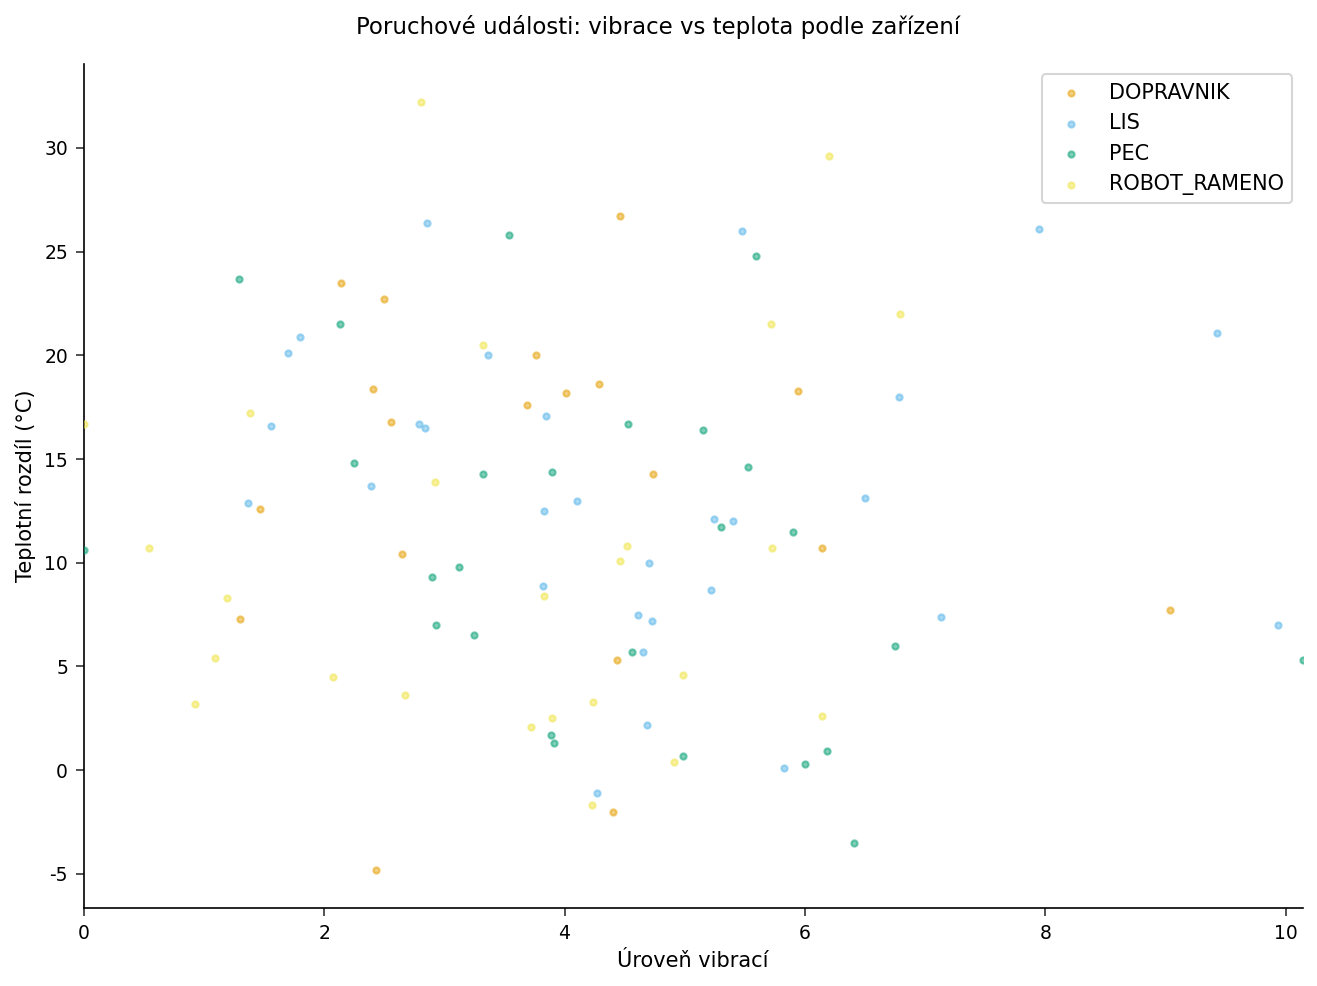

In [3]:
/* --------------------------------------------------------
   Vibrace vs teplotní rozdíl podle typu zařízení
   -------------------------------------------------------- */
PROCEDURA SGPLOT data=work.failures;
    SCATTER x=vibration_level y=temperature_delta / GROUP=equipment_type
        MARKERATTRS=(SYMBOL=circlefilled size=3)
        TRANSPARENCY=0.5;
    ŠTÍTEK equipment_type='Typ zařízení';
    XAXIS ŠTÍTEK='Úroveň vibrací';
    YAXIS ŠTÍTEK='Teplotní rozdíl (°C)';
    NÁZEV 'Poruchové události: vibrace vs teplota podle zařízení';
SPUSTIT;


---

In [4]:
/* --------------------------------------------------------
   Standardize symptom variables for clustering
   -------------------------------------------------------- */
PROCEDURA STANDARD data=work.failures out=work.failures_std
    mean=0 std=1;
    PROMĚNNÁ vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
SPUSTIT;


NOTE: PROC STANDARD data=work.failures

NOTE: Standardized 100 rows, 8 variables.


                                      Profily příznaků poruch podle typu zařízení                                       

                                                 The CLUSTER Procedure
                                           Complete Linkage Cluster Analysis

                                          Eigenvalues of the Covariance Matrix

                                                    Cluster History

   NCL    --------Clusters Joined--------    FREQ    SPRSQ      RSQ    Distance

    99    FE-00005          FE-00006        2    0.0007    0.9993          1
    98    FE-00007          FE-00008        2    0.0007    0.9986          1
    97    FE-00000          FE-00004        2    0.0009    0.9977        1.2
    96    FE-00002          FE-00008        2    0.0009    0.9968        1.2
    95    FE-00000          FE-00001        2    0.0010    0.9958        1.3
    94    FE-00005          FE-00008        2    0.0011    0.9947        1.3
    93    FE-00004          CL99     


NOTE: PROC CLUSTER data=work.failures_std method=Complete

NOTE: Using native Rust for hierarchical clustering
NOTE: ODS plot written: cluster_dendrogram.spec.json
NOTE: PROC CLUSTER ODS Graphics generated.
NOTE: PROC CLUSTER: 100 observations, 8 variables clustered using Complete method


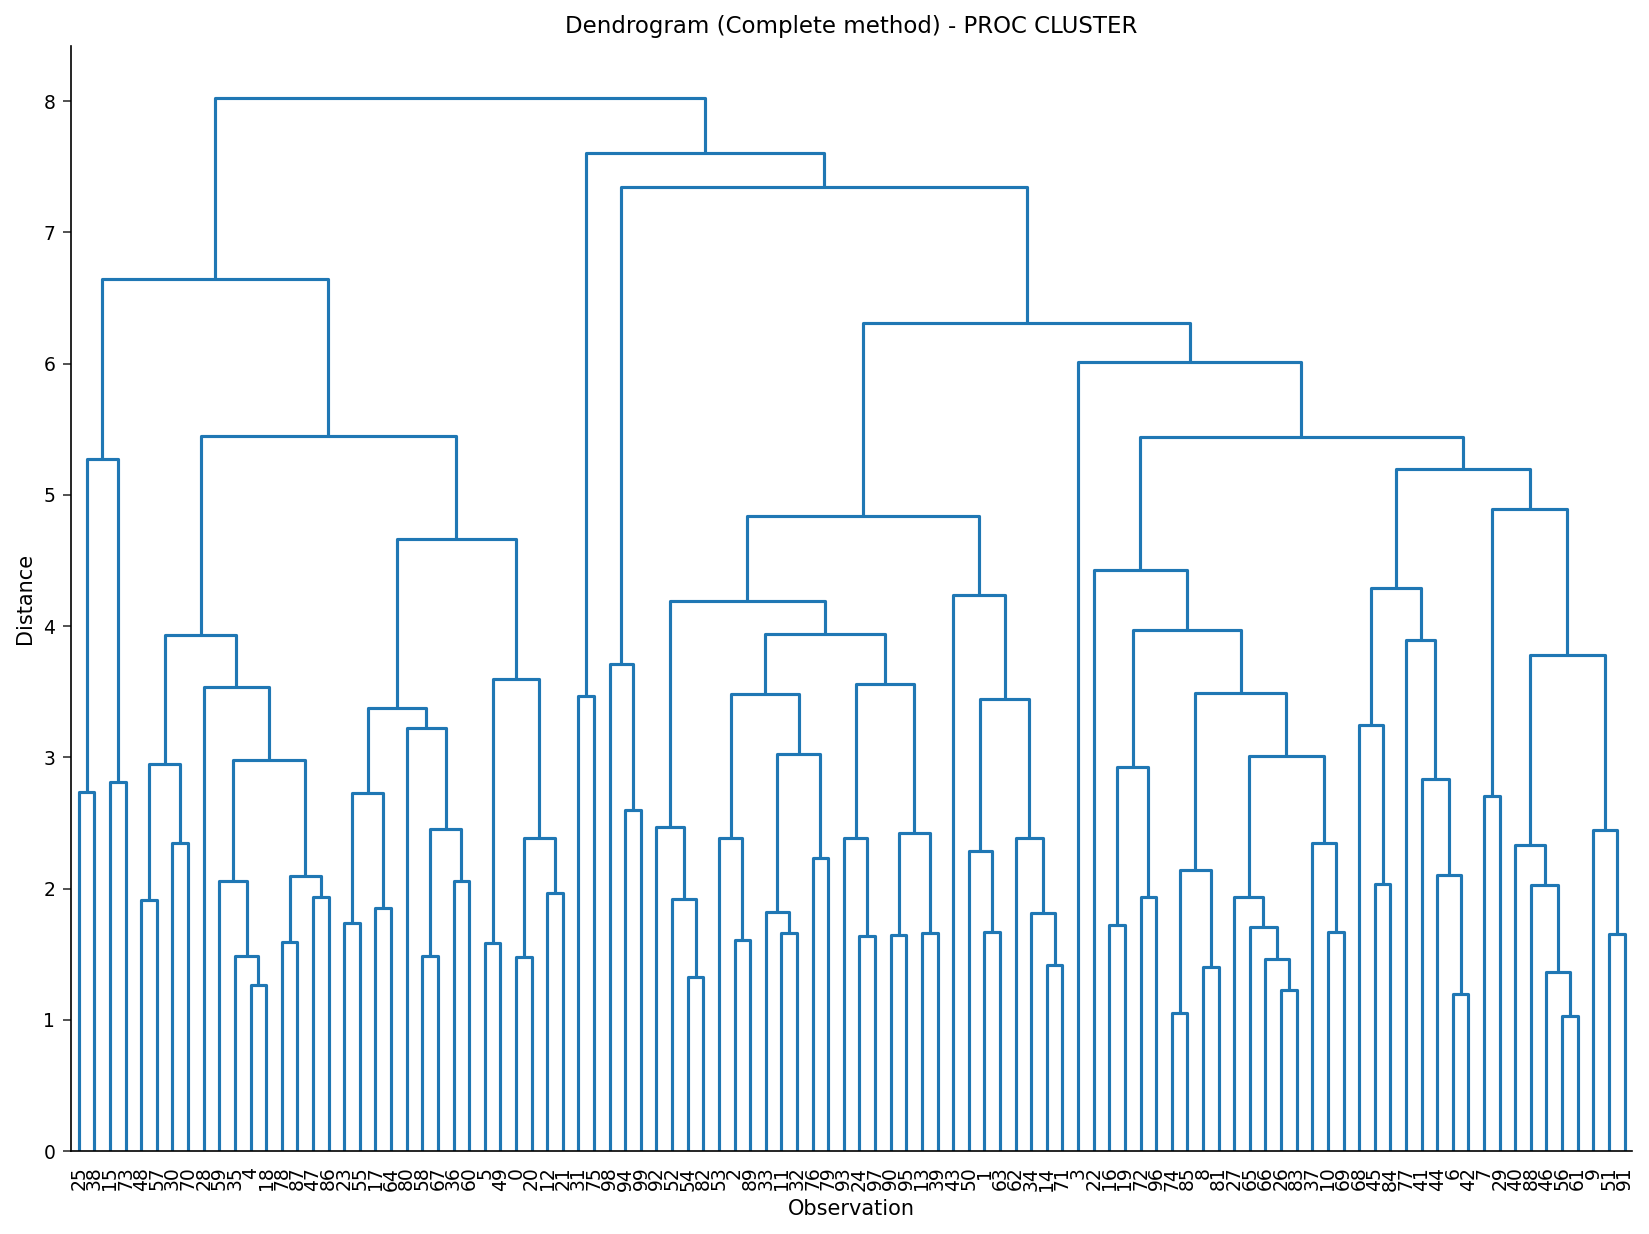

In [5]:
/* --------------------------------------------------------
   Shlukování s úplným propojením s TRIM= pro odstranění
   odlehlých hodnot. TRIM=5 odstraní 5 % nejvzdálenějších
   pozorování před vytvořením shluků.
   -------------------------------------------------------- */
PROCEDURA CLUSTER data=work.failures_std METHOD=complete
    outtree=work.failure_tree
    pseudo TISK=20 trim=5;
    PROMĚNNÁ vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
    ŠTÍTEK vibration_level='Úroveň vibrací'
          temperature_delta='Teplotní rozdíl'
          pressure_drop='Pokles tlaku'
          current_spike='Proudová špička'
          noise_db='Hluk (dB)'
          cycle_time_deviation='Odchylka doby cyklu'
          torque_variance='Rozptyl krouticího momentu'
          oil_particle_count='Počet částic v oleji'
          downtime_minutes='Prostoj (min)'
          equipment_type='Typ zařízení'
          shift='Směna'
          failure_mode='Režim poruchy';
    id failure_id;
SPUSTIT;


In [6]:
/* --------------------------------------------------------
   Cut the complete-linkage hierarchy into six failure
   modes with PROC TREE (NCLUSTERS=6). Six is chosen as a
   practical, interpretable granularity for triage; the
   dendrogram above shows the merge structure that this
   cut partitions.
   -------------------------------------------------------- */
PROCEDURA TREE data=work.failure_tree
    out=work.failure_mode_assignments
    nclusters=6;
    id failure_id;
SPUSTIT;

                                      Profily příznaků poruch podle typu zařízení                                       




NOTE: PROC TREE data=work.failure_tree

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: PROC TREE dendrogram SVG generated.
NOTE: PROC TREE: Extracted 6 clusters using Python/scipy


In [7]:
/* --------------------------------------------------------
   Připoj přiřazení a profiluj režimy poruch
   -------------------------------------------------------- */
data work.failures_classified;
    SLOUČIT work.failures
          work.failure_mode_assignments(PŘEJMENOVAT=(CLUSTER=failure_mode));
    PODLE failure_id;
SPUSTIT;

PROCEDURA PRŮMĚRY data=work.failures_classified n mean std;
    TŘÍDA failure_mode;
    PROMĚNNÁ vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance
        oil_particle_count downtime_minutes;
    ŠTÍTEK vibration_level='Úroveň vibrací'
          temperature_delta='Teplotní rozdíl'
          pressure_drop='Pokles tlaku'
          current_spike='Proudová špička'
          noise_db='Hluk (dB)'
          cycle_time_deviation='Odchylka doby cyklu'
          torque_variance='Rozptyl krouticího momentu'
          oil_particle_count='Počet částic v oleji'
          downtime_minutes='Prostoj (min)'
          equipment_type='Typ zařízení'
          shift='Směna'
          failure_mode='Režim poruchy';
    NÁZEV 'Profily příznaků režimů poruch (k=6)';
SPUSTIT;


                                          Profily příznaků režimů poruch (k=6)                                          

                                                  The MEANS Procedure

                                 Analysis Variable : vibration_level Úroveň vibrací

        Režim poruchy           N Obs           Mean        Std Dev
        -----------------------------------------------------------
        1                          17      4.3470588      2.6168582
        2                          17      4.2552941      2.2610427
        3                          17      3.6870588      1.8669720
        4                          17      4.0500000      2.0351843
        5                          16      3.4793750      1.4636870
        6                          16      4.9693750      1.6907177
        -----------------------------------------------------------

                                Analysis Variable : temperature_delta Teplotní rozdíl

        Režim poruchy 


NOTE: DATA work.failures_classified

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.failures_classified (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                                     Rozložení režimů poruch podle zařízení a směny                                     

                                                   The FREQ Procedure

Table of Režim poruchy by Typ zařízení

Režim poruchy  |   DOPRAVNIK |         LIS |         PEC |ROBOT_RAMENO |        Total
---------------+-------------+-------------+-------------+-------------+-------------
1              |           4 |           7 |           5 |           1 |           17
---------------+-------------+-------------+-------------+-------------+-------------
2              |           3 |           2 |           5 |           7 |           17
---------------+-------------+-------------+-------------+-------------+-------------
3              |           6 |           2 |           5 |           4 |           17
---------------+-------------+-------------+-------------+-------------+-------------
4              |           1 |           7 |           5 |           4 |       


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_failure_mode_equipment_type.spec.json
NOTE: ODS plot written: freq_mosaic_failure_mode_shift.spec.json
NOTE: PROC FREQ statement used.


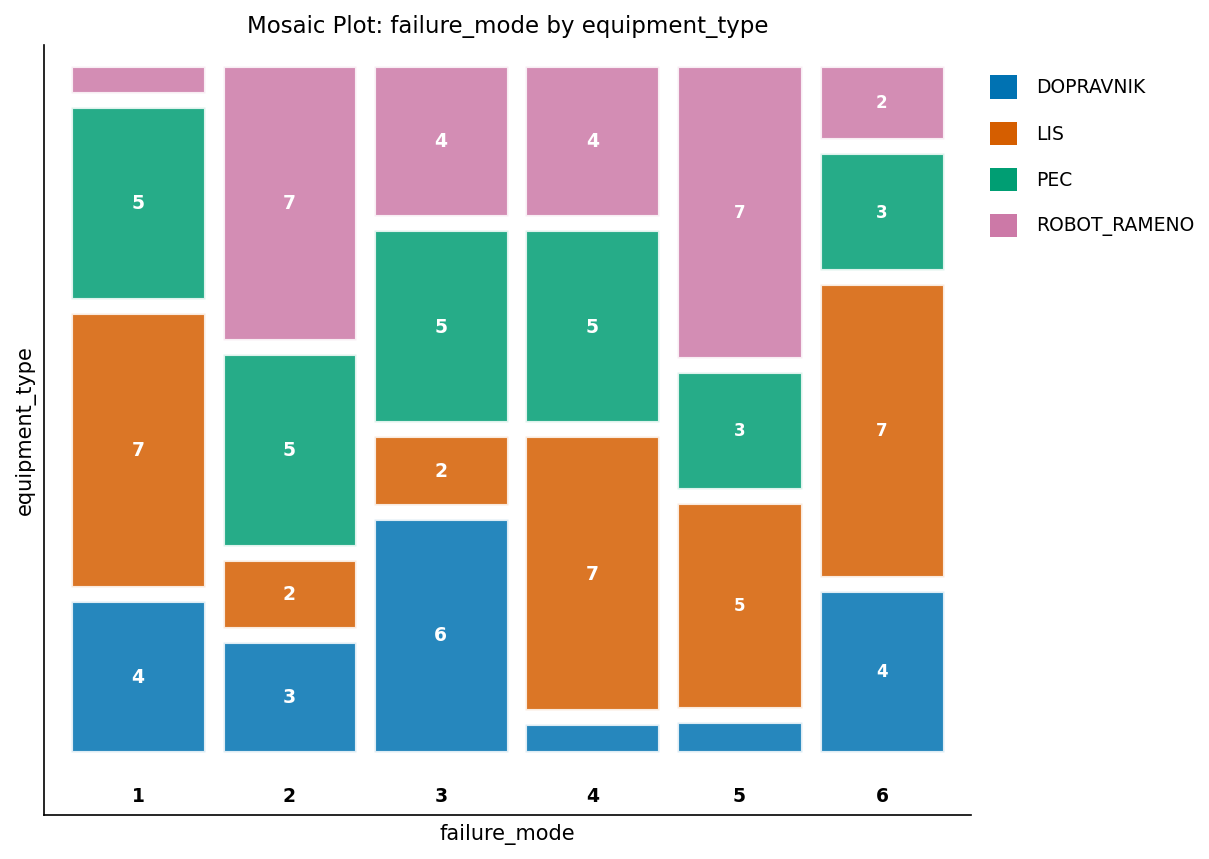

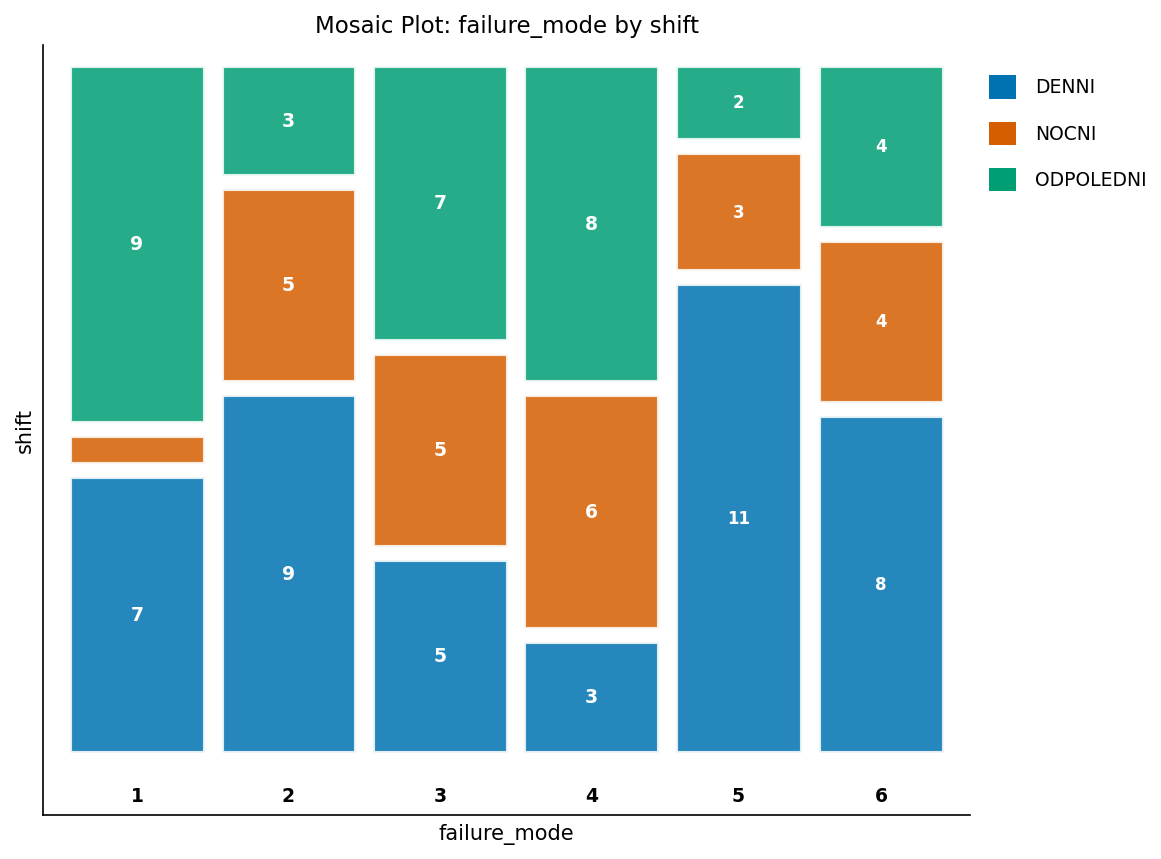

In [8]:
/* --------------------------------------------------------
   Křížová tabulace režimů poruch podle typu zařízení
   a směny k odhalení systematických vzorců
   -------------------------------------------------------- */
PROCEDURA ČETNOSTI data=work.failures_classified;
    TABLES failure_mode * equipment_type / chisq nocol nopercent;
    TABLES failure_mode * shift / chisq nocol nopercent;
    ŠTÍTEK vibration_level='Úroveň vibrací'
          temperature_delta='Teplotní rozdíl'
          pressure_drop='Pokles tlaku'
          current_spike='Proudová špička'
          noise_db='Hluk (dB)'
          cycle_time_deviation='Odchylka doby cyklu'
          torque_variance='Rozptyl krouticího momentu'
          oil_particle_count='Počet částic v oleji'
          downtime_minutes='Prostoj (min)'
          equipment_type='Typ zařízení'
          shift='Směna'
          failure_mode='Režim poruchy';
    NÁZEV 'Rozložení režimů poruch podle zařízení a směny';
SPUSTIT;


---

### Interpretace

Shlukování 100 standardizovaných poruchových událostí metodou úplného propojení dává **šest režimů poruch** téměř stejné velikosti (n = 17, 17, 17, 17, 16, 16). Režimy se odlišují svými symptomatickými signaturami v profilu `PROC MEANS` výše:

- **Režim 6** nese nejsilnější signaturu mechanického namáhání: nejvyšší průměrné vibrace (4,97), nejvyšší pokles tlaku (7,51) a nejvyšší proudovou špičku (1,61) — ale **nejnižší** rozptyl krouticího momentu (1,28).
- **Režim 3** je tepelný režim: nejvyšší teplotní rozdíl (16,3 °C) s nejnižším průměrným hlukem (73,0 dB).
- **Režim 2** má **nejdelší dobu odstávky** s velkým odstupem (průměr 85,6 minuty oproti 31–52 u ostatních režimů) a zvýšený rozptyl krouticího momentu (3,57), což ukazuje na události, jejichž náprava je nákladnější.
- **Režim 4** je nejmírnější: nejnižší doba odstávky (31,4 minuty) a podprůměrný pokles tlaku i počet částic v oleji.
- **Režimy 1 a 5** jsou skupiny se smíšenými symptomy bez jediného převažujícího faktoru.

Křížové tabulace `PROC FREQ` testují, zda se tyto režimy koncentrují u konkrétních zařízení nebo směn. Při této velikosti vzorku tomu tak **není**: režim × typ zařízení dává chí-kvadrát = 20,48 (15 st. v., p = 0,154, Cramérovo V = 0,26) a režim × směna dává chí-kvadrát = 17,13 (10 st. v., p = 0,072, Cramérovo V = 0,29) — oba nad prahem 0,05, a přes 80 % buněk má očekávané četnosti nižší než 5, takže samotný chí-kvadrát je pouze orientační. Viditelné náklony (režim 6 se přiklání k LIS, režim 5 k denní směně) jsou zde spíše popisné než významné.

**Závěr:** úplné propojení na standardizovaných symptomatických profilech vytváří interpretovatelnou taxonomii šesti režimů odvozenou od teploty, tlaku a doby odstávky. K potvrzení, zda se režimy mapují na konkrétní zařízení nebo směny — což je použitelná otázka po hlavní příčině — potřebuje analýza celou historii událostí, nikoli tento vzorek 100 událostí, kde zůstávají křížové tabulace nedostatečně silné.

---

In [9]:
/* --------------------------------------------------------
   Export failure classifications for CMMS integration
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.failures_classified
    OUTFILE='failure_mode_classifications.csv'
    DBMS=csv REPLACE;
SPUSTIT;


NOTE: PROC EXPORT data=work.failures_classified outfile=failure_mode_classifications.csv

NOTE: Exported 100 rows to failure_mode_classifications.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Poháněno platformou <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>